# Introducción a redes neuronales

+ **Observación importante**: En Google Colab TensorFlow ya viene preinstalado por defecto.

In [ ]:
import tensorflow as tf

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import precision_score, recall_score, f1_score

+ En esta sesión volveremos a trabajar con el dataset de e-mails: algunos son spam y otros no. El objetivo es identificar correctamente son spam.

In [ ]:
# La raw URL del CSV en GitHub
url = 'https://raw.githubusercontent.com/EduardoSelimMM/2026PrimaveraUP_ML/refs/heads/main/sesion21/spam_email_dataset.csv'

# Se lee el CSV y se guarda en un pandas DataFrame
df = pd.read_csv(url)

In [ ]:
df.head()

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


In [ ]:
# Sin mucho análisis o justificación se quitarán los NAs
df = df.dropna()

In [ ]:
variables_numericas = [
    'num_words', 'num_characters', 'num_exclamation_marks',
    'num_links', 'num_attachments', 'sender_reputation_score', 'num_recipients'
]

variables_categoricas = [
    'has_suspicious_link', 'has_attachment', 'email_hour',
    'is_weekend', 'contains_money_terms', 'contains_urgency_terms'
]

# Se define quienes serán tanto la variable objetivo, como las variables explicativas
y = df['label']
X = df[variables_numericas]

In [ ]:
# División de datos (entrenamiento y prueba)
# 20% como datos de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2026)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_numericas)
    ]
)

# Ajustar y transformar los datos de entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# Transformar los datos de test (usando el ajuste de train)
X_test_processed = preprocessor.transform(X_test)

# El número de columnas resultantes después de la transformación
dim_input = X_train_processed.shape[1]

In [ ]:
dim_input

7

In [ ]:
model = Sequential([
    # Capa de entrada pura (solo define la forma de los datos de entrada)
    Input(shape=(dim_input,)),

    # Primera capa oculta
    Dense(4, activation = 'relu'),

    # Segunda capa oculta
    Dense(6, activation = 'relu'),

    # Capa de salida
    Dense(1, activation = 'sigmoid')
])

In [ ]:
# Información básica del modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69 (276.00 B)

 Trainable params: 69 (276.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilación del modelo
model.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

# Entrenamiento del modelo
model.fit(X_train_processed, y_train, epochs = 20, batch_size = 10, verbose = 1)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7182 - loss: 0.5199
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7811 - loss: 0.4317
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7934 - loss: 0.4164
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7946 - loss: 0.4083
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7947 - loss: 0.4020
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7986 - loss: 0.3945
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8025 - loss: 0.3869
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8043 - loss: 0.3796
Epoch 9/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8039 - loss: 0.3728
Epoch 10/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8062 - loss: 0.3680
Epoch 11/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8083 - loss: 0.3649
Epoch 12/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

## Diferencia importante con respecto a otros modelos que se han entrenado antes

+ Cuando se usa Tensorflow/Keras se requiere un paso adicional de **compilación**, que antes no teníamos.

+ La **compilación** (`.compile`) es la traducción de la arquitectura de capas a un grafo de computación que el hardware (CPU o GPU) pueda ejecutar. Básicamente, se le está comunicando al hardware la función matemática que se va a minimizar.

+ El **entrenamiento** (`.fit`) es darle los datos del fenómeno que estamos analizando para que con éstos resuelva el problema de optimización.

+ `optimizer`: Es el algoritmo matemático que calcula las derivadas. Su trabajo es resolver la ecuación
$$\theta_{new} = \theta_{old} - \eta \cdot \nabla J(\theta)$$
donde $\theta$ son los pesos, $\eta$ la tasa de aprendizaje y $\nabla J$ el error.

+ `loss`: Representa a loss function (función de pérdida). Es la función que cuantifica la diferencia entre la predicción y la realidad.

+ `metrics`: Son funciones adicionales que corren en paralelo para que tú, el humano, veas un número comprensible (0% a 100%), ya que el valor de la "pérdida" suele ser un número abstracto difícil de interpretar.

### En el .fit()

+ Recuérdese que el entrenamiento es un proceso iterativo de optimización de una función matemática.

+ La red no procesa todos los datos a la vez (sería muy pesado para la memoria) ni tampoco uno por uno (sería muy lento).

  + `batch_size` es un parámetro que define el tamaño de un bloque. Por ejemplo, `batch_size = 10` divide al dataset de entrenamiento en bloques de 10 observaciones. El modelo procesa esas 10 observaciones, calcula el error promedio de ese bloque y realiza una actualización de los pesos.

  + Un `batch_size` pequeño suele dar una estimación del gradiente más "ruidosa" pero ayuda a salir de mínimos locales; uno grande es más estable pero requiere más memoria RAM.

  + Una "época" termina cuando el algoritmo ha pasado por el dataset completo una vez.

  + Por ejemplo, si se tiene un dataset de entrenamiento con 1000 observaciones y un `batch_size = 10`, cada época tendrá 100 actualizaciones de pesos (1000 / 10).

  + Con `epochs = 20`, el algoritmo repetirá este proceso de 100 actualizaciones un total de 20 veces.
  
  + Muy pocas épocas pueden llevar a  underfitting (el modelo no ajustó sus pesos lo suficiente). Demasiadas épocas causan overfitting (el modelo se ajusta tanto al ruido de los datos de entrenamiento que pierde capacidad de generalizar).

+ Es decir, los parámetros `batch_size` y `epochs` controlan la eficiencia y la frecuencia con la que se actualizan los coeficientes (pesos) de la función a optimizar.

+ El parámetro `verbose` no tiene que ver con el proceso de optimización. Es un parámetro para darle un poco de paz a la persona que está programando la red neuronal.

  + `verbose = 0`: Modo silencioso. No imprime nada en la consola mientras entrena.

  + `verbose = 1`: Muestra una barra de progreso animada por cada época (útil para ver si la pérdida baja en tiempo real).

  + `verbose = 2`: Imprime una línea por cada época indicando el tiempo y el valor de la pérdida.

In [ ]:
# Se evalúa el performance
loss, accuracy = model.evaluate(X_test_processed, y_test)
print(f"Test Accuracy: {accuracy:.2%}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8225 - loss: 0.3507
Test Accuracy: 82.25%


+ **IMPORTANTE:** Se puede obtener una métrica de desempeño del modelo **SIN** predecir explícitamente sobre todo el dataset de prueba.

+ **AÚN MÁS IMPORTANTE**: Si se quiere más información sobre qué tan bien lo hace el modelo, sí se requiere obtener predicciones explícitas sobre todo el dataset de prueba.

In [ ]:
# Se obtienen las probabilidades estimadas de ser de la clase "1"
y_probs_test = model.predict(X_test_processed).ravel()

# Se convierte las probabilidades a clases binarias (0 o 1)
# Si la probabilidad estimada es > 0.5 es clase 1, de lo contrario es clase 0
y_pred_test = (y_probs_test > 0.5).astype("int32")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


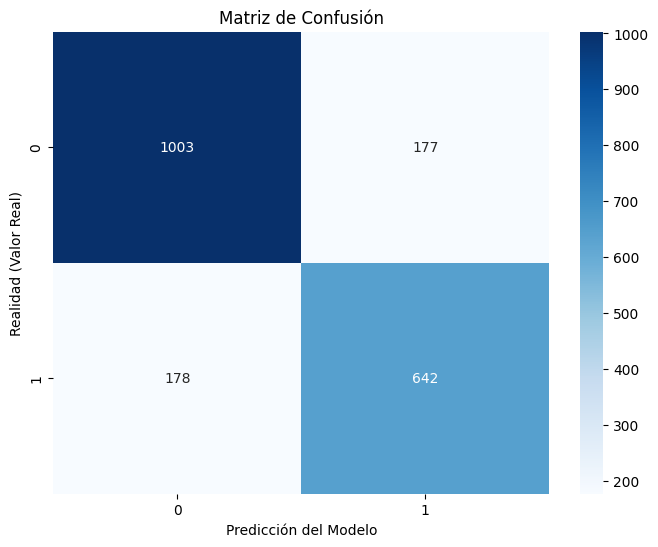

In [ ]:
# Se obtiene la matriz de confusión sobre los datos de prueba
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

# Graficamos
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1'],
            yticklabels=['0', '1'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Valor Real)')
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
print(f"Recall: {recall_score(y_test, y_pred_test)}")
print(f"Precision: {precision_score(y_test, y_pred_test)}")
print(f"Tasa Falsos Negativos: {fn / (tp + fn)}")
print(f"Tasa Falsos Positivos: {fp / (tn + fp)}")
print(f"Especificidad: {tn / (tn + fp)}")

Recall: 0.7829268292682927
Precision: 0.7838827838827839
Tasa Falsos Negativos: 0.21707317073170732
Tasa Falsos Positivos: 0.15
Especificidad: 0.85


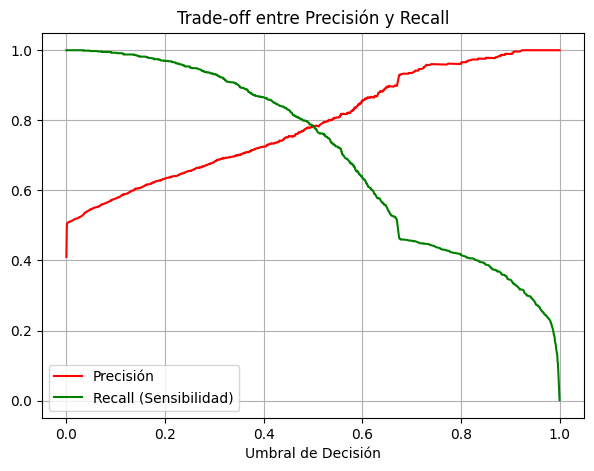

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_test, pos_label=1)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], label="Precisión", color="red")
plt.plot(thresholds, recall[:-1], label="Recall (Sensibilidad)", color="green")
plt.xlabel("Umbral de Decisión")
plt.title("Trade-off entre Precisión y Recall")
plt.legend()
plt.grid(True)
plt.show()

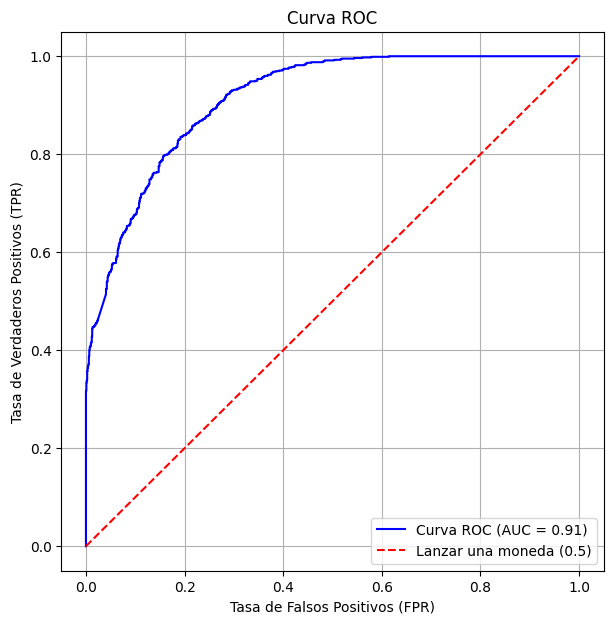

In [ ]:
# Se puede graficar tanto la precisión como el recall para cada umbral
# Especificamos explícitamente que el '1' es el evento que nos interesa
fpr, tpr, thresholds = roc_curve(y_test, y_probs_test)

# Se obtiene el área bajo la curva (AUC)
auc = roc_auc_score(y_test, y_probs_test)

# Se dibuja la curva ROC
plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='blue', label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Lanzar una moneda (0.5)') # Línea de referencia

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

# El ejemplo más famoso: MNIST

+ El conjunto de datos MNIST es el "Hola Mundo" de la visión por computadora.

+ Consiste en 70,000 imágenes en escala de grises (28×28 píxeles) de dígitos escritos a mano del 0 al 9.

+ Como ahora estamos prediciendo 10 categorías (0–9) en lugar de sólo dos, este es un problema de **clasificación multiclase**.

+ Es tan famoso el ejemplo, que la librería de TensorFlow la trae para jugar con ella.


In [ ]:
from tensorflow.keras.datasets import mnist

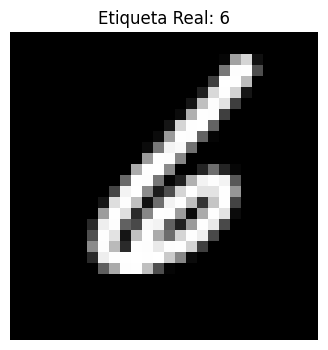

In [ ]:
# Cargamos los datos
(X_train, y_train), _ = mnist.load_data()

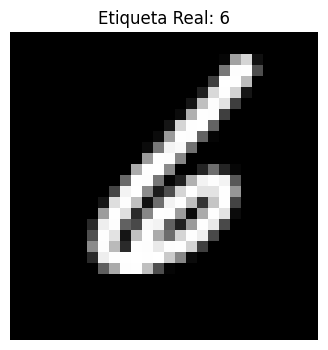

In [ ]:
# Elegimos un índice al azar (por ejemplo, la imagen número 999)
indice = 999
imagen = X_train[indice]
etiqueta = y_train[indice]

# Configuramos la visualización
plt.figure(figsize=(4, 4)) # Tamaño de la figura
plt.imshow(imagen, cmap='gray') # 'gray' para escala de grises
plt.title(f'Etiqueta Real: {etiqueta}') # Título con la clase correcta
plt.axis('off') # Ocultar los ejes numéricos (0-28)
plt.show()

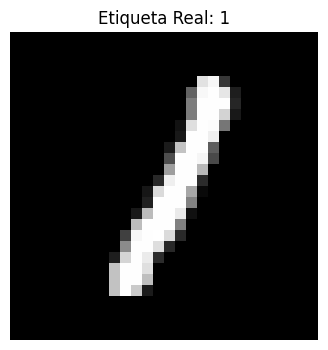

In [ ]:
# Otra imagen
indice = 345
imagen = X_train[indice]
etiqueta = y_train[indice]

# Configuramos la visualización
plt.figure(figsize=(4, 4)) # Tamaño de la figura
plt.imshow(imagen, cmap='gray') # 'gray' para escala de grises
plt.title(f'Etiqueta Real: {etiqueta}') # Título con la clase correcta
plt.axis('off') # Ocultar los ejes numéricos (0-28)
plt.show()

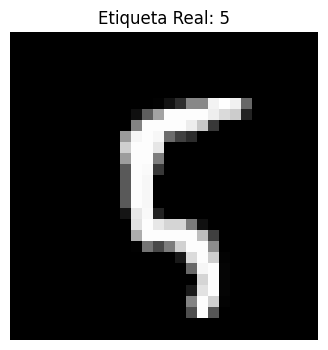

In [ ]:
# Otra imagen
indice = 100
imagen = X_train[indice]
etiqueta = y_train[indice]

# Configuramos la visualización
plt.figure(figsize=(4, 4)) # Tamaño de la figura
plt.imshow(imagen, cmap='gray') # 'gray' para escala de grises
plt.title(f'Etiqueta Real: {etiqueta}') # Título con la clase correcta
plt.axis('off') # Ocultar los ejes numéricos (0-28)
plt.show()

In [ ]:
# Se cargan los datos
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Se normalizan los valores de los pixeles de (0-255) a (0-1)
X_train, X_test = X_train / 255.0, X_test / 255.0

model = Sequential([
    # Cada dato de entrenamiento consiste de una matriz de 28x28 con la información de los pixeles
    Input(shape = (28, 28)),
    # Se agrega la función Flatten() para convertir el dato de 28x28 a un único vector de 784 entradas
    Flatten(),

    # Hidden layers
    Dense(128, activation = 'relu'),
    Dense(64, activation = 'relu'),

    # Output layer: 10 neuronas (una por cada digito)
    # Softmax garantiza que la suma de las 10 neuronas sume 1 (para que se puedan interpretar como probabilidades)
    Dense(10, activation = 'softmax')
])

# También cambiamos de métrica 'sparse_categorical_crossentropy' pues las etiquetas son 0, 1, 2..., 9
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Entrenamiento de la red
model.fit(X_train, y_train, epochs = 5, batch_size = 32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9282 - loss: 0.2434
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9690 - loss: 0.1030
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9776 - loss: 0.0720
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9822 - loss: 0.0556
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9865 - loss: 0.0438


In [ ]:
# Accuracy de las predicciones sobre el dataset de prueba
loss, acc = model.evaluate(X_test, y_test)
print(f"Accuracy en el test set: {acc:.2%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9718 - loss: 0.0885
Accuracy on test set: 97.18%


### Algunas predicciones puntuales

In [ ]:
un_dato_de_prueba = X_test[7:8] # El octavo en este caso

In [ ]:
prediccion = model.predict(un_dato_de_prueba)
digito_predecido = np.argmax(prediccion) # Encuentra el índice de la probabilidad más alta
print(f"El modelo predice que el dígito es: {digito_predecido}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
El modelo predice que el dígito es: 9


In [ ]:
# Observen que la predicción de una observación devuelve un vector de probabilidades
prediccion

array([[2.45468459e-06, 1.68874431e-06, 2.02618025e-06, 4.09329878e-05,
        6.23191241e-04, 1.19047465e-04, 5.70862113e-09, 1.09383582e-04,
        1.45444676e-04, 9.98955846e-01]], dtype=float32)

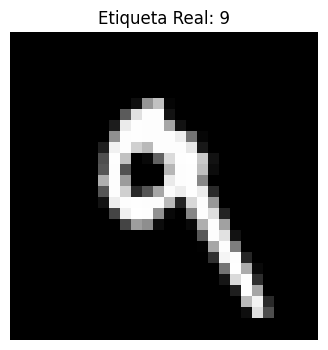

In [ ]:
# Veamos el dato exacto
imagen_a_predecir = 8-1
imagen = X_test[imagen_a_predecir]
etiqueta = y_test[imagen_a_predecir]

# Configuramos la visualización
plt.figure(figsize=(4, 4)) # Tamaño de la figura
plt.imshow(imagen, cmap='gray') # 'gray' para escala de grises
plt.title(f'Etiqueta Real: {etiqueta}') # Título con la clase correcta
plt.axis('off') # Ocultar los ejes numéricos (0-28)
plt.show()

In [ ]:
otro_dato_de_prueba = X_test[32:33] # El 33-avo en este caso
prediccion = model.predict(otro_dato_de_prueba)
digito_predecido = np.argmax(prediccion) # Encuentra el índice de la probabilidad más alta
print(f"El modelo predice que el dígito es: {digito_predecido}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
El modelo predice que el dígito es: 3


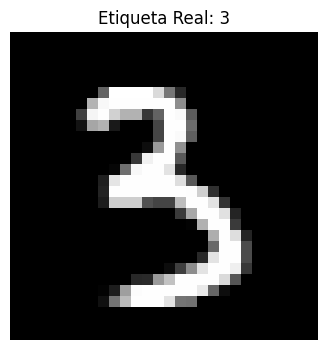

In [ ]:
# Veamos el dato exacto
imagen_a_predecir = 33-1
imagen = X_test[imagen_a_predecir]
etiqueta = y_test[imagen_a_predecir]

# Configuramos la visualización
plt.figure(figsize=(4, 4)) # Tamaño de la figura
plt.imshow(imagen, cmap='gray') # 'gray' para escala de grises
plt.title(f'Etiqueta Real: {etiqueta}') # Título con la clase correcta
plt.axis('off') # Ocultar los ejes numéricos (0-28)
plt.show()

In [ ]:
# Se obtienen las probabilidades predecidas para TODO el set de prueba (10,000 imágenes)
predicciones_probs = model.predict(X_test)

# Se convierten esas probabilidades a dígitos, seleccionando el de mayor probabilidad
predicciones_digitos = np.argmax(predicciones_probs, axis=1)

# Se compara con las etiquetas reales
# Esto crea un array de booleanos: True donde acertó, False donde falló
comparacion = (predicciones_digitos == y_test)

# Se cuentan los aciertos
total_correctas = np.sum(comparacion)
total_imagenes = len(y_test)
porcentaje = (total_correctas / total_imagenes) * 100

print(f"Predicciones correctas: {total_correctas} de {total_imagenes}")
print(f"Precisión (Accuracy): {porcentaje:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predicciones correctas: 9718 de 10000
Precisión (Accuracy): 97.18%


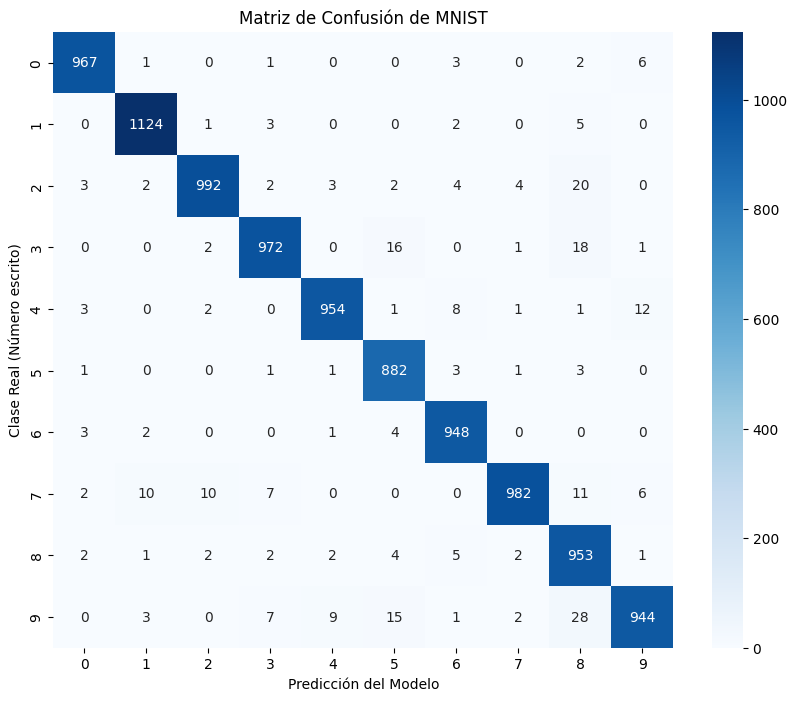

In [ ]:
# Se puede también crear una matriz de confusión
cm = confusion_matrix(y_test, predicciones_digitos)

# Se grafica la matriz
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real (Número escrito)')
plt.title('Matriz de Confusión de MNIST')
plt.show()